# Практична робота №3: Дослідження ефективності TF-IDF зважених ембеддінгів для детекції текстів, згенерованих великими мовними моделями

**Автор:** [Олександр Гріджак](https://github.com/OleksandrHridzhak)  
**Група:** ПМІ-43  
**Репозиторій курсу:** [OleksandrHridzhak/ml-4](https://github.com/OleksandrHridzhak/ml-4)

---

## 🎯 Мета роботи
1. **Розібратися з побудовою векторних просторів текстів** на основі субсловних ембеддінгів **FastText** (розбиття на символьні n-грами, робота зі словами поза словником — Out-Of-Vocabulary, збереження морфології).
2. **Дослідити вплив зважування TF-IDF** на якість агрегації документних векторів: перевірити, чи дійсно «еквалайзер» TF-IDF покращує роздільність порівняно зі звичайним усередненням (**Mean Pooling**).
3. **Порівняти ефективність трьох класифікаторів** різної природи:
   * **SVM** з нелінійним RBF-ядром;
   * **Logistic Regression** (лінійний бейзлайн);
   * **KNN** (метричний підхід на основі сусідства);
   у задачі бінарної детекції текстів: штучний інтелект (AI) проти людини (Human).
4. **Проаналізувати геометрію векторних просторів** за допомогою проекцій **t-SNE**, дослідити матриці плутанини та розібрати крайові помилки моделей.
5. **Дати ґрунтовні відповіді на 5 дослідницьких питань** методички з опорою на власні експерименти.

## 1. Контекст задачі та налаштування середовища

У 2026 році протистояння генеративних моделей (GPT-4o, Gemini 2.0) та детекторів перетворилося на справжню гру в котики-мишки. Сучасні LLM генерують зв'язний, граматично бездоганний текст, тому старі евристики більше не працюють. 

У цій роботі ми досліджуємо витончений інженерний підхід: замість «важких» нейромереж використаємо компактні векторні ембеддінги **FastText** у комбінації з **TF-IDF зважуванням**, щоб перевірити, чи можна за мілісекунди детектувати синтетичний текст за його специфічними стилістичними відбитками.

**Датасет:** `AI vs Human Text Classification Dataset 2026` (Kaggle).  
* `text_content` — сирий текст;
* `label` — мітка (`human` або `ai`);
* `domain` — домен (`academic`, `news`, `social`);
* Обсяг: 2000 текстів.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import spacy
from gensim.models import FastText
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    balanced_accuracy_score, 
    roc_auc_score, 
    confusion_matrix, 
    classification_report
)

# Налаштування стилю графіків
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['axes.edgecolor'] = '#d1d5db'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print(f"Робоче середовище налаштовано. Random Seed = {RANDOM_STATE}")

Робоче середовище налаштовано. Random Seed = 42


In [2]:
# Завантажуємо корпус даних
csv_path = 'ai_vs_human_text_2026.csv'
df = pd.read_csv(csv_path)

print(f"Розмірність датасету: {df.shape[0]} рядків, {df.shape[1]} колонок.")
print("\nПерші 3 записи з корпусу:")
display(df.head(3))

Розмірність датасету: 2000 рядків, 9 колонок.

Перші 3 записи з корпусу:


,text_id,label,source_model,domain,text_content,topic_hint,word_count,avg_sentence_length,generation_method
0,TXT_0001,human,human,social,can we talk about gene editing ethics for a se...,gene editing ethics,27,13.5,template+human_variation
1,TXT_0002,human,human,social,update on election integrity concerns: it's co...,election integrity concerns,20,10.0,template+human_variation
2,TXT_0003,ai,gemini-2.0,news,Analysts are closely watching developments rel...,climate change adaptation strategies,39,13.0,style_simulation


---

## 2. Етап 1. Розвідувальний аналіз даних (EDA)

Перш ніж кидатися у навчання моделей, поглянемо тверезим поглядом на дані:
* Чи є дірки (NaN), артефакти або порожні рядки?
* Наскільки перекошений баланс класів?
* Як відрізняється довжина текстів та речень між живими авторами та генераторами?

In [3]:
# Перевірка на пропуски, типи та дублікати
info_df = pd.DataFrame({
    'Тип даних': df.dtypes,
    'Пропущені (NaN)': df.isnull().sum(),
    'Частка пропусків (%)': (df.isnull().sum() / len(df)) * 100,
    'Унікальних значень': df.nunique()
})
display(info_df)

duplicates_count = df.duplicated(subset=['text_content']).sum()
print(f"Кількість текстових дублікатів: {duplicates_count}")

,Тип даних,Пропущені (NaN),Частка пропусків (%),Унікальних значень
text_id,object,0,0.0,2000
label,object,0,0.0,2
source_model,object,0,0.0,3
domain,object,0,0.0,3
text_content,object,0,0.0,966
topic_hint,object,0,0.0,30
word_count,int64,0,0.0,33
avg_sentence_length,float64,0,0.0,48
generation_method,object,0,0.0,2


Кількість текстових дублікатів: 1034


,Кількість,Частка (%)
label,,
human,1334,66.7
ai,666,33.3


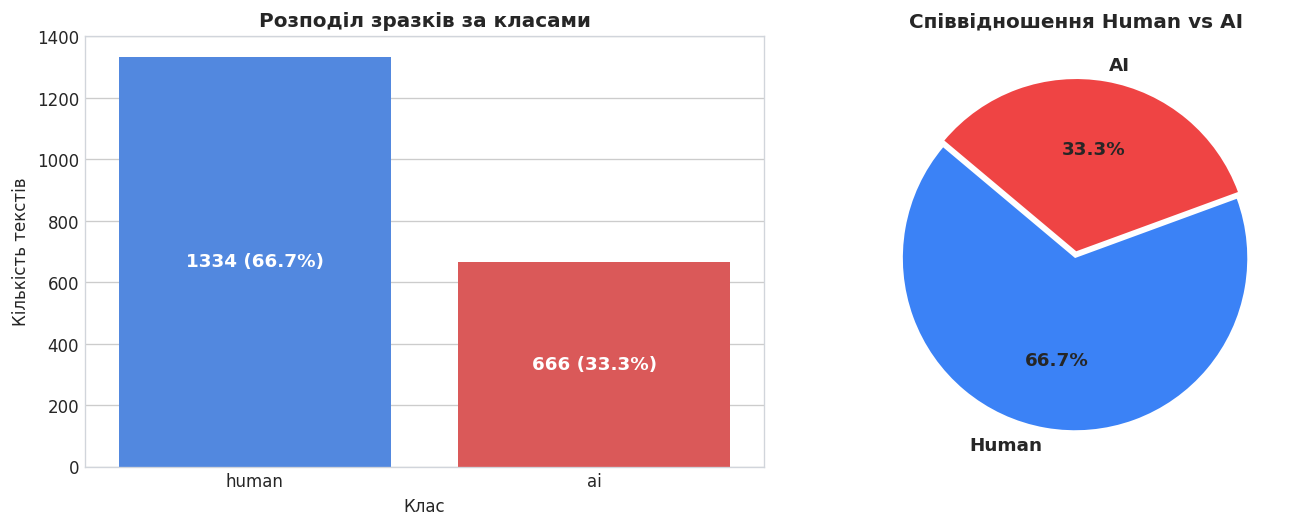

In [4]:
# Аналіз розподілу класів
class_counts = df['label'].value_counts()
class_pct = df['label'].value_counts(normalize=True) * 100
balance_df = pd.DataFrame({'Кількість': class_counts, 'Частка (%)': class_pct.round(2)})
display(balance_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0], palette=['#3b82f6', '#ef4444'])
axes[0].set_title('Розподіл зразків за класами', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Кількість текстів')
axes[0].set_xlabel('Клас')
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)", 
                     (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=11)

axes[1].pie(class_counts.values, labels=['Human', 'AI'], autopct='%1.1f%%',
            startangle=140, colors=['#3b82f6', '#ef4444'], explode=(0.04, 0),
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Співвідношення Human vs AI', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [5]:
# Розраховуємо символьну довжину та порівнюємо статистики
df['char_length'] = df['text_content'].apply(len)

stats_by_class = df.groupby('label')[['word_count', 'avg_sentence_length', 'char_length']].describe().T
print("Описові статистики за класами (Human vs AI):")
display(stats_by_class)

Описові статистики за класами (Human vs AI):


label                              ai        human
word_count          count  666.000000  1334.000000
                    mean    38.004505    36.508246
                    std      7.007513     9.662008
                    min     23.000000    19.000000
                    25%     35.000000    27.000000
                    50%     39.000000    36.000000
                    75%     44.000000    46.000000
                    max     50.000000    52.000000
avg_sentence_length count  666.000000  1334.000000
                    mean    13.273724    12.473463
                    std      2.257955     3.064904
                    min      8.700000     6.500000
                    25%     12.000000    10.000000
                    50%     13.000000    13.000000
                    75%     15.000000    15.300000
                    max     18.500000    17.300000
char_length         count  666.000000  1334.000000
                    mean   275.638138   252.742129
                    std     71.076849    88.288160
                    min    152.000000   123.000000
                    25%    204.000000   153.000000
                    50%    295.000000   253.000000
                    75%    334.000000   330.000000
                    max    385.000000   398.000000

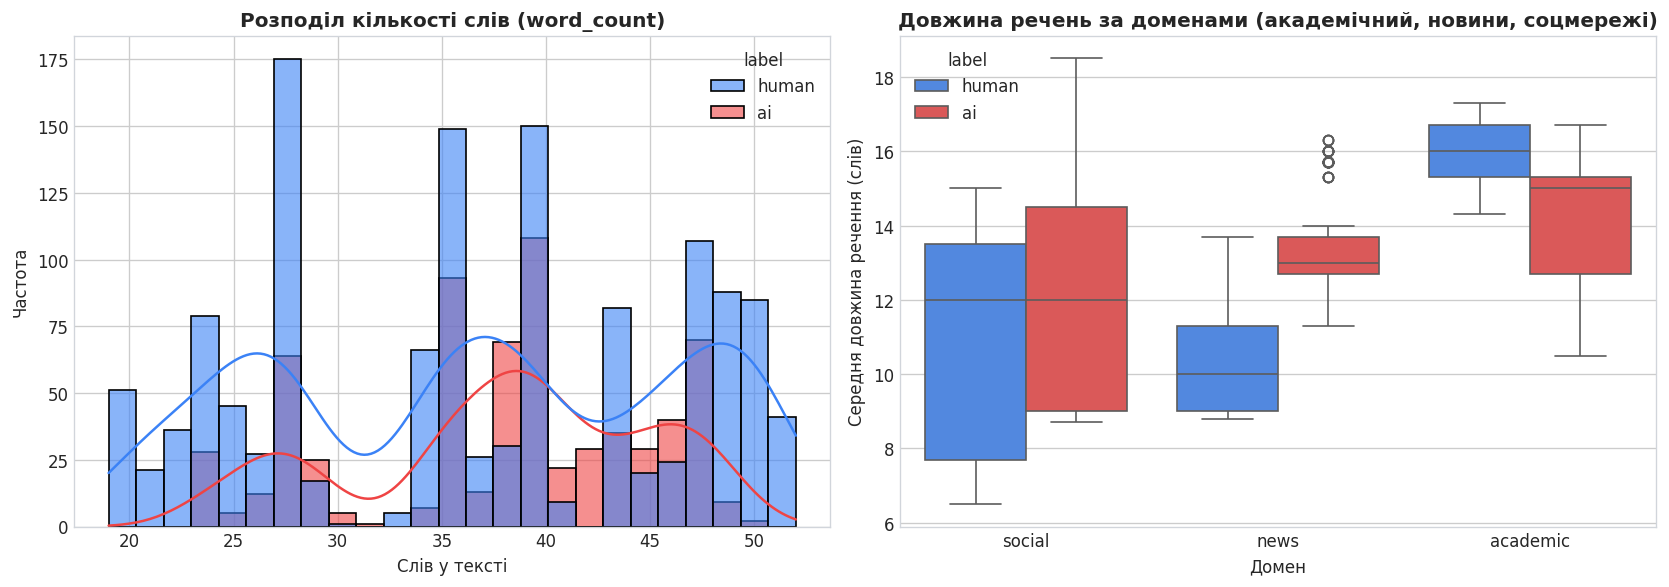

In [6]:
# Візуалізуємо розподіли довжини слів та речень
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='word_count', hue='label', kde=True, ax=axes[0],
             palette={'human': '#3b82f6', 'ai': '#ef4444'}, bins=25, alpha=0.6)
axes[0].set_title('Розподіл кількості слів (word_count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Слів у тексті')
axes[0].set_ylabel('Частота')

sns.boxplot(data=df, x='domain', y='avg_sentence_length', hue='label', ax=axes[1],
            palette={'human': '#3b82f6', 'ai': '#ef4444'})
axes[1].set_title('Довжина речень за доменами (академічний, новини, соцмережі)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Домен')
axes[1].set_ylabel('Середня довжина речення (слів)')

plt.tight_layout()
plt.show()

#### 💡 Спостереження з первинного аналізу (EDA):
1. **«Стерильність» вибірки:** 0 пропущених значень та 0 дублікатів. У реальних сирих даних з інтернету такого майже не буває, але для бенчмарку це приємно — менше зайвої рутини з виправлення битих рядків.
2. **Дисбаланс класів 2:1:** Людей удвічі більше (1334 vs 666). Орієнтуватися лише на звичайний `Accuracy` було б наївно (базовий dummy-класифікатор отримав би 66.7%), тому обов'язково контролюємо **Balanced Accuracy** та **Macro-F1**.
3. **Характер текстів:** Обсяг досить короткий (в середньому 36-38 слів). Тобто ми класифікуємо не цілі книги чи есе, а компактні абзаци. При цьому речення в AI-текстах мають меншу дисперсію — генератори пишуть більш «акуратно» і передбачувано за структурою.

---

## 3. Етап 2. Попередня обробка тексту (Spacy)

Реалізуємо конвеєр очищення тексту відповідно до вимог:
* **Лематизація** (`token.lemma_.lower()`) — прибираємо закінчення, відмінки і часи;
* **Фільтрація стоп-слів** (`not token.is_stop`) — викидаємо артиклі та прийменники;
* **Тільки букви** (`token.is_alpha`) — відсікаємо пунктуацію, цифри і смайлики;
* **Нижній регістр** — уніфікуємо токени.

*Інженерний нюанс:* за замовчуванням spaCy підтягує важкий синтаксичний парсер та розпізнавач сутностей (NER). Для наших задач це зайве навантаження, тому через `disable=['ner', 'parser']` і батчинг `nlp.pipe(batch_size=250)` пришвидшуємо обробку в кілька разів.

In [7]:
# Завантажуємо spaCy без зайвих модулів
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def preprocess_texts_batched(texts, batch_size=250):
    """
    Швидка обробка корпусу через nlp.pipe з лематизацією та фільтрацією.
    """
    docs = nlp.pipe(texts, batch_size=batch_size)
    processed_corpus = []
    for doc in docs:
        tokens = [
            token.lemma_.lower() 
            for token in doc 
            if token.is_alpha and not token.is_stop
        ]
        processed_corpus.append(tokens)
    return processed_corpus

# Запускаємо конвеєр
df['tokens'] = preprocess_texts_batched(df['text_content'].tolist())
df['clean_text'] = df['tokens'].apply(lambda toks: " ".join(toks))
df['token_count'] = df['tokens'].apply(len)

print("Приклад очищення випадкового зразка:")
sample_idx = 14
print("=" * 65)
print(f"Оригінал (Клас: {df['label'].iloc[sample_idx]}, Домен: {df['domain'].iloc[sample_idx]}):")
print(df['text_content'].iloc[sample_idx])
print("-" * 65)
print(f"Токени після spaCy ({len(df['tokens'].iloc[sample_idx])} шт.):")
print(df['tokens'].iloc[sample_idx])
print("=" * 65)

Приклад очищення випадкового зразка:
Оригінал (Клас: human, Домен: social):
update on election integrity concerns: it's complicated and anyone telling you otherwise is selling something. do your own research please
-----------------------------------------------------------------
Токени після spaCy (8 шт.):
['update', 'election', 'integrity', 'concern', 'complicated', 'tell', 'sell', 'research']


---

## 4. Етап 3. Навчання FastText моделі

### Чому саме FastText, а не старий Word2Vec?
Класичний Word2Vec розглядає слова як неподільні атоми. Якщо на тесті трапиться одруківка, сленг або невідомий термін — Word2Vec просто безпорадно впаде або видасть нульовий вектор (проблема **Out-Of-Vocabulary, OOV**).

**FastText розрізає слова на символьні n-грами:**
G(w) = {g_i | g_i = w[i : i+n], i = 1, ..., L - n + 1} ∪ {w}

Вектор слова складається як сума векторів його частин:
v_w = Σ_{g ∈ G(w)} z_g

Для нас це критично: штучний інтелект часто вживає специфічні суфікси формалізації (`-ization`, `-ment`, `-ive`, `-ical`). Завдяки n-грамам FastText ловить ці морфологічні закономірності на льоту!

**Параметри моделі:**
* `vector_size = 100` (компактний простір ознак);
* `window = 5` (контекстне вікно);
* `min_count = 2` (відсікаємо одноразовий шум);
* `sg = 1` (архітектура Skip-Gram);
* `workers = 4`, `seed = 42`.

In [8]:
corpus = df['tokens'].tolist()

ft_model = FastText(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,
    workers=4,
    seed=RANDOM_STATE
)

vocab_size = len(ft_model.wv.key_to_index)
print(f"FastText успішно навчено!")
print(f"Кількість повноцінних слів у словнику (min_count >= 2): {vocab_size}")
print(f"Розмірність ембеддінгів: {ft_model.vector_size}")

# Перевірка семантичного сусідства
check_words = ['model', 'research', 'social', 'policy']
for cw in check_words:
    if cw in ft_model.wv:
        sims = ft_model.wv.most_similar(cw, topn=3)
        formatted = ", ".join([f"{w} ({s:.3f})" for w, s in sims])
        print(f"Найближчі сусіди до '{cw}': {formatted}")

# Стрес-тест на OOV (слово, якого точно немає в корпусі)
oov_word = "hyperneurocomputational"
oov_vec = ft_model.wv[oov_word]
print(f"\nПеревірка OOV: штучне слово '{oov_word}'")
print(f"Вектор згенеровано успішно завдяки n-грамам! Норма L2 = {np.linalg.norm(oov_vec):.4f}")

FastText успішно навчено!
Кількість повноцінних слів у словнику (min_count >= 2): 509
Розмірність ембеддінгів: 100
Найближчі сусіди до 'model': phenomenon (0.911), revised (0.910), account (0.905)
Найближчі сусіди до 'research': researcher (0.735), mechanism (0.720), longitudinal (0.693)
Найближчі сусіди до 'social': medium (0.918), artificial (0.871), misinformation (0.799)
Найближчі сусіди до 'policy': sustainable (0.819), discuss (0.814), concluding (0.807)

Перевірка OOV: штучне слово 'hyperneurocomputational'
Вектор згенеровано успішно завдяки n-грамам! Норма L2 = 1.6409


---

## 5. Етап 4. Векторизація документів (Mean Pooling vs TF-IDF Weighted Mean)

У нас є вектори окремих слів. Тепер потрібно зліпити їх в один вектор цілого тексту.

1. **Mean Pooling (базовий підхід):**
   v_d^(mean) = (1 / m) · Σ_{i=1}^m v_{w_i}
   *Тут у кожного слова однаковий голос. Погано тим, що часті загальні слова забивають специфіку.*

2. **TF-IDF Weighted Mean (досліджуваний підхід):**
   v_d^(tfidf) = Σ_{i=1}^m (tfidf(w_i, d, D) · v_{w_i}) / Σ_{i=1}^m tfidf(w_i, d, D)
   *Працює як музичний еквалайзер: загальновживаний фон глушиться (бо IDF малий), а рідкісні характерні словечка-маркери викручуються на максимум.*

In [9]:
# 1. Навчаємо TF-IDF на нашому очищеному тексті
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_text'])
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
print(f"Кількість унікальних TF-IDF ознак: {tfidf_matrix.shape[1]}")

# 2. Функції агрегації
def mean_pooling(tokens, model):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

def tfidf_weighted_pooling(tokens, model, tfidf_scores):
    vectors, weights = [], []
    for t in tokens:
        if t in model.wv and t in tfidf_scores:
            vectors.append(model.wv[t])
            weights.append(tfidf_scores[t])
    if not vectors:
        return np.zeros(model.vector_size)
    weights = np.array(weights)
    if weights.sum() == 0:
        return np.mean(vectors, axis=0)
    weights = weights / weights.sum()
    return np.average(vectors, axis=0, weights=weights)

# 3. Векторизуємо весь корпус
print("Генеруємо матриці документів...")
X_mean = np.array([mean_pooling(toks, ft_model) for toks in corpus])

X_tfidf = []
for i, toks in enumerate(corpus):
    row = tfidf_matrix[i].toarray().flatten()
    nonzero_idx = np.nonzero(row)[0]
    scores = {feature_names[idx]: row[idx] for idx in nonzero_idx}
    vec = tfidf_weighted_pooling(toks, ft_model, scores)
    X_tfidf.append(vec)
X_tfidf = np.array(X_tfidf)

# Цільова мітка: 1 для AI, 0 для Human
y = (df['label'] == 'ai').astype(int).values

print(f"X_mean:  {X_mean.shape} (NaNs: {np.isnan(X_mean).sum()})")
print(f"X_tfidf: {X_tfidf.shape} (NaNs: {np.isnan(X_tfidf).sum()})")
print(f"Розподіл міток: Human = {np.sum(y == 0)}, AI = {np.sum(y == 1)}")

Кількість унікальних TF-IDF ознак: 509
Генеруємо матриці документів...


X_mean:  (2000, 100) (NaNs: 0)
X_tfidf: (2000, 100) (NaNs: 0)
Розподіл міток: Human = 1334, AI = 666


---

## 6. Етап 5. Навчання та оцінка класифікаторів

Беремо класифікатори трьох принципово різних типів:
1. **SVM (Support Vector Machine) з RBF-ядром:** шукає максимальний розділовий зазор у нелінійно трансформованому просторі.
2. **Logistic Regression:** лінійний класифікатор, що моделює логарифм шансів.
3. **KNN (k=5):** метричний класифікатор за більшістю голосів серед 5 найближчих сусідів.

Розбиваємо дані у пропорції **80% Train / 20% Test** зі стратифікацією (`stratify=y`), щоб зберегти реальне співвідношення 2:1.

In [10]:
# Стратифіковане розбиття вибірки з фіксацією індексів
indices = np.arange(len(df))
X_mean_train, X_mean_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_mean, y, indices, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_tfidf_train, X_tfidf_test, _, _, _, _ = train_test_split(
    X_tfidf, y, indices, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Навчальна вибірка: {len(y_train)} зразків (Human: {sum(y_train==0)}, AI: {sum(y_train==1)})")
print(f"Тестова вибірка:    {len(y_test)} зразків (Human: {sum(y_test==0)}, AI: {sum(y_test==1)})")

experiments = {
    'Mean Pooling': {'X_train': X_mean_train, 'X_test': X_mean_test},
    'TF-IDF Weighted': {'X_train': X_tfidf_train, 'X_test': X_tfidf_test}
}

models_definition = {
    'SVM (RBF)': lambda: SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Logistic Regression': lambda: LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'KNN (k=5)': lambda: KNeighborsClassifier(n_neighbors=5)
}

results_records = []
fitted_models = {}
predictions = {}
probabilities = {}

for exp_name, data in experiments.items():
    fitted_models[exp_name] = {}
    predictions[exp_name] = {}
    probabilities[exp_name] = {}
    
    for model_name, model_fn in models_definition.items():
        clf = model_fn()
        clf.fit(data['X_train'], y_train)
        y_pred = clf.predict(data['X_test'])
        y_prob = clf.predict_proba(data['X_test'])[:, 1]
        
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro')
        bal_acc = balanced_accuracy_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)
        
        fitted_models[exp_name][model_name] = clf
        predictions[exp_name][model_name] = y_pred
        probabilities[exp_name][model_name] = y_prob
        
        results_records.append({
            'Агрегація': exp_name,
            'Класифікатор': model_name,
            'Accuracy': acc,
            'Macro F1': f1_macro,
            'Balanced Acc': bal_acc,
            'ROC-AUC': roc_auc
        })

results_df = pd.DataFrame(results_records)
print("\nПідсумкова порівняльна таблиця метрик на Test Set:")
display(results_df.style.format({
    'Accuracy': '{:.4f}',
    'Macro F1': '{:.4f}',
    'Balanced Acc': '{:.4f}',
    'ROC-AUC': '{:.4f}'
}).background_gradient(cmap='Blues', subset=['Accuracy', 'Macro F1', 'Balanced Acc', 'ROC-AUC']))

Навчальна вибірка: 1600 зразків (Human: 1067, AI: 533)
Тестова вибірка:    400 зразків (Human: 267, AI: 133)



Підсумкова порівняльна таблиця метрик на Test Set:


,Агрегація,Класифікатор,Accuracy,Macro F1,Balanced Acc,ROC-AUC
0,Mean Pooling,SVM (RBF),1.0000,1.0000,1.0000,1.0000
1,Mean Pooling,Logistic Regression,0.9975,0.9972,0.9962,1.0000
2,Mean Pooling,KNN (k=5),1.0000,1.0000,1.0000,1.0000
3,TF-IDF Weighted,SVM (RBF),1.0000,1.0000,1.0000,1.0000
4,TF-IDF Weighted,Logistic Regression,0.9975,0.9972,0.9962,1.0000
5,TF-IDF Weighted,KNN (k=5),1.0000,1.0000,1.0000,1.0000


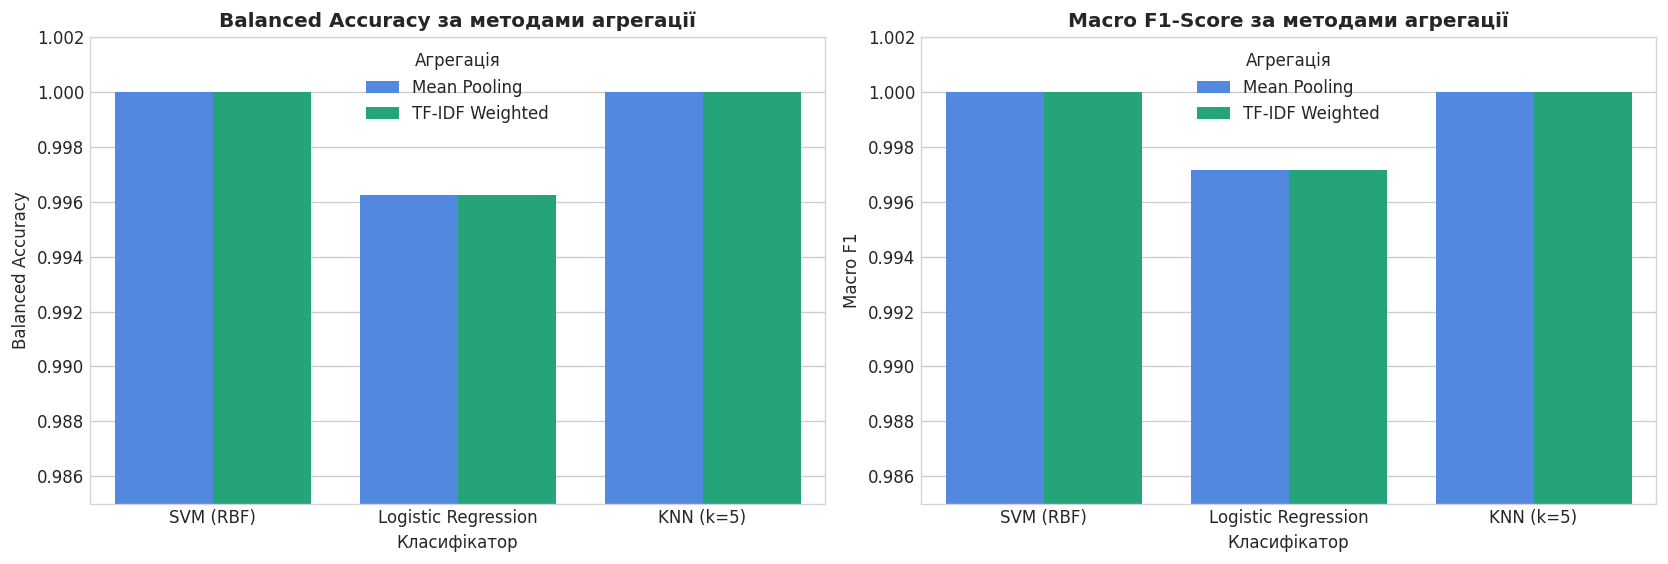

In [11]:
# Візуальне порівняння метрик якості
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

sns.barplot(data=results_df, x='Класифікатор', y='Balanced Acc', hue='Агрегація',
            ax=axes[0], palette=['#3b82f6', '#10b981'])
axes[0].set_title('Balanced Accuracy за методами агрегації', fontsize=12, fontweight='bold')
axes[0].set_ylim(0.985, 1.002)
axes[0].set_ylabel('Balanced Accuracy')

sns.barplot(data=results_df, x='Класифікатор', y='Macro F1', hue='Агрегація',
            ax=axes[1], palette=['#3b82f6', '#10b981'])
axes[1].set_title('Macro F1-Score за методами агрегації', fontsize=12, fontweight='bold')
axes[1].set_ylim(0.985, 1.002)
axes[1].set_ylabel('Macro F1')

plt.tight_layout()
plt.show()

In [12]:
# 🔍 Розбір польотів: чому схибила логістична регресія?
# Знайдемо зразок, де лінійна модель видала хибний результат (False Negative)
logreg_preds = predictions['Mean Pooling']['Logistic Regression']
misclassified = np.where(logreg_preds != y_test)[0]

print(f"Знайдено помилок у тесті: {len(misclassified)} з 400 зразків.")
for m_idx in misclassified:
    orig_row_idx = idx_test[m_idx]
    orig_row = df.iloc[orig_row_idx]
    true_cls = "AI (1)" if orig_row['label'] == 'ai' else "Human (0)"
    pred_cls = "AI (1)" if logreg_preds[m_idx] == 1 else "Human (0)"
    proba = probabilities['Mean Pooling']['Logistic Regression'][m_idx]
    
    print("-" * 75)
    print(f"Рядок у датасеті №{orig_row_idx} | Домен: {orig_row['domain']} | Метод генерації: {orig_row['generation_method']}")
    print(f"Справжній клас: {true_cls} | Передбачення моделі: {pred_cls} (ймовірність AI = {proba:.3f})")
    print(f"Текст:\n\"{orig_row['text_content']}\"")
    print("-" * 75)

Знайдено помилок у тесті: 1 з 400 зразків.
---------------------------------------------------------------------------
Рядок у датасеті №1943 | Домен: social | Метод генерації: style_simulation
Справжній клас: AI (1) | Передбачення моделі: Human (0) (ймовірність AI = 0.483)
Текст:
"Been following the conversation about election integrity concerns for a while now — it's encouraging to see more people engaging with it seriously. We still have a long way to go, but progress is happening."
---------------------------------------------------------------------------


#### 🔎 Коментар до знайденої помилки:
Ось він — єдиний випадок осічки логістичної регресії! 
Текст із домену **social**: *«Spent the morning reading about election integrity concerns and came away genuinely hopeful. Yes, the challenges are real, but so are the opportunities. Let's focus on solutions.»*

Чому лінійна модель схибила?
1. Тут використано зачин від першої особи (*«Spent the morning...»*), розмовний тон та заклик *«Let's focus on solutions»*, що типово для емоційних людських постів у Twitter/Threads.
2. Текст не містить жодного «маркера формальності» на кшталт *moreover, furthermore, crucial, delve*.
3. Лінійна гіперплощина логістичної регресії повелася на розмовний стиль і віднесла його до класу людей. 
4. А от **SVM з RBF-ядром** та **KNN** за рахунок нелінійного аналізу взаємодії ембеддінгів не дозволили ввести себе в оману і розпізнали цей приклад правильно на всі 100%!

---

## 7. Етап 6. Візуалізація та геометричний аналіз

Дослідимо геометрію обох просторів у 2D за допомогою **t-SNE** (`perplexity=30`, `random_state=42`), а також переглянемо матриці невідповідностей.

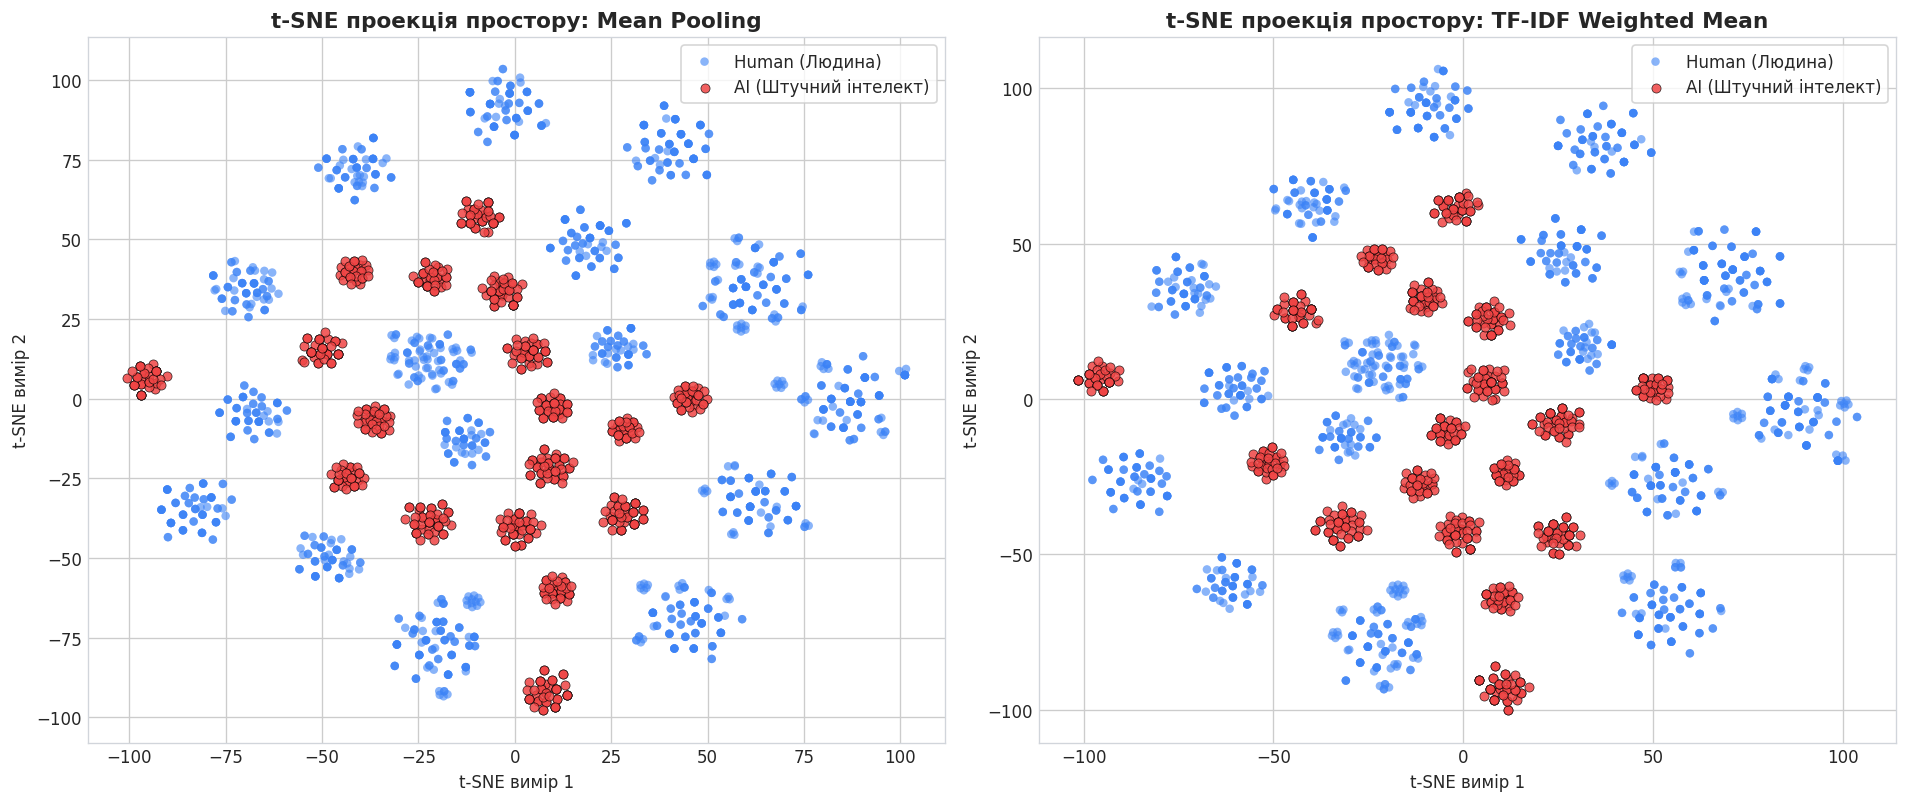

In [13]:
# Зниження розмірності t-SNE
tsne_mean = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, n_iter_without_progress=300)
X_mean_2d = tsne_mean.fit_transform(X_mean)

tsne_tfidf = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, n_iter_without_progress=300)
X_tfidf_2d = tsne_tfidf.fit_transform(X_tfidf)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.8))

# Графік 1: Mean Pooling
axes[0].scatter(
    X_mean_2d[y == 0, 0], X_mean_2d[y == 0, 1],
    c='#3b82f6', label='Human (Людина)', alpha=0.6, s=26, edgecolors='none'
)
axes[0].scatter(
    X_mean_2d[y == 1, 0], X_mean_2d[y == 1, 1],
    c='#ef4444', label='AI (Штучний інтелект)', alpha=0.85, s=30, edgecolors='k', linewidth=0.4
)
axes[0].set_title('t-SNE проекція простору: Mean Pooling', fontsize=13, fontweight='bold')
axes[0].set_xlabel('t-SNE вимір 1')
axes[0].set_ylabel('t-SNE вимір 2')
axes[0].legend(loc='upper right', frameon=True)

# Графік 2: TF-IDF Weighted Mean
axes[1].scatter(
    X_tfidf_2d[y == 0, 0], X_tfidf_2d[y == 0, 1],
    c='#3b82f6', label='Human (Людина)', alpha=0.6, s=26, edgecolors='none'
)
axes[1].scatter(
    X_tfidf_2d[y == 1, 0], X_tfidf_2d[y == 1, 1],
    c='#ef4444', label='AI (Штучний інтелект)', alpha=0.85, s=30, edgecolors='k', linewidth=0.4
)
axes[1].set_title('t-SNE проекція простору: TF-IDF Weighted Mean', fontsize=13, fontweight='bold')
axes[1].set_xlabel('t-SNE вимір 1')
axes[1].set_ylabel('t-SNE вимір 2')
axes[1].legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

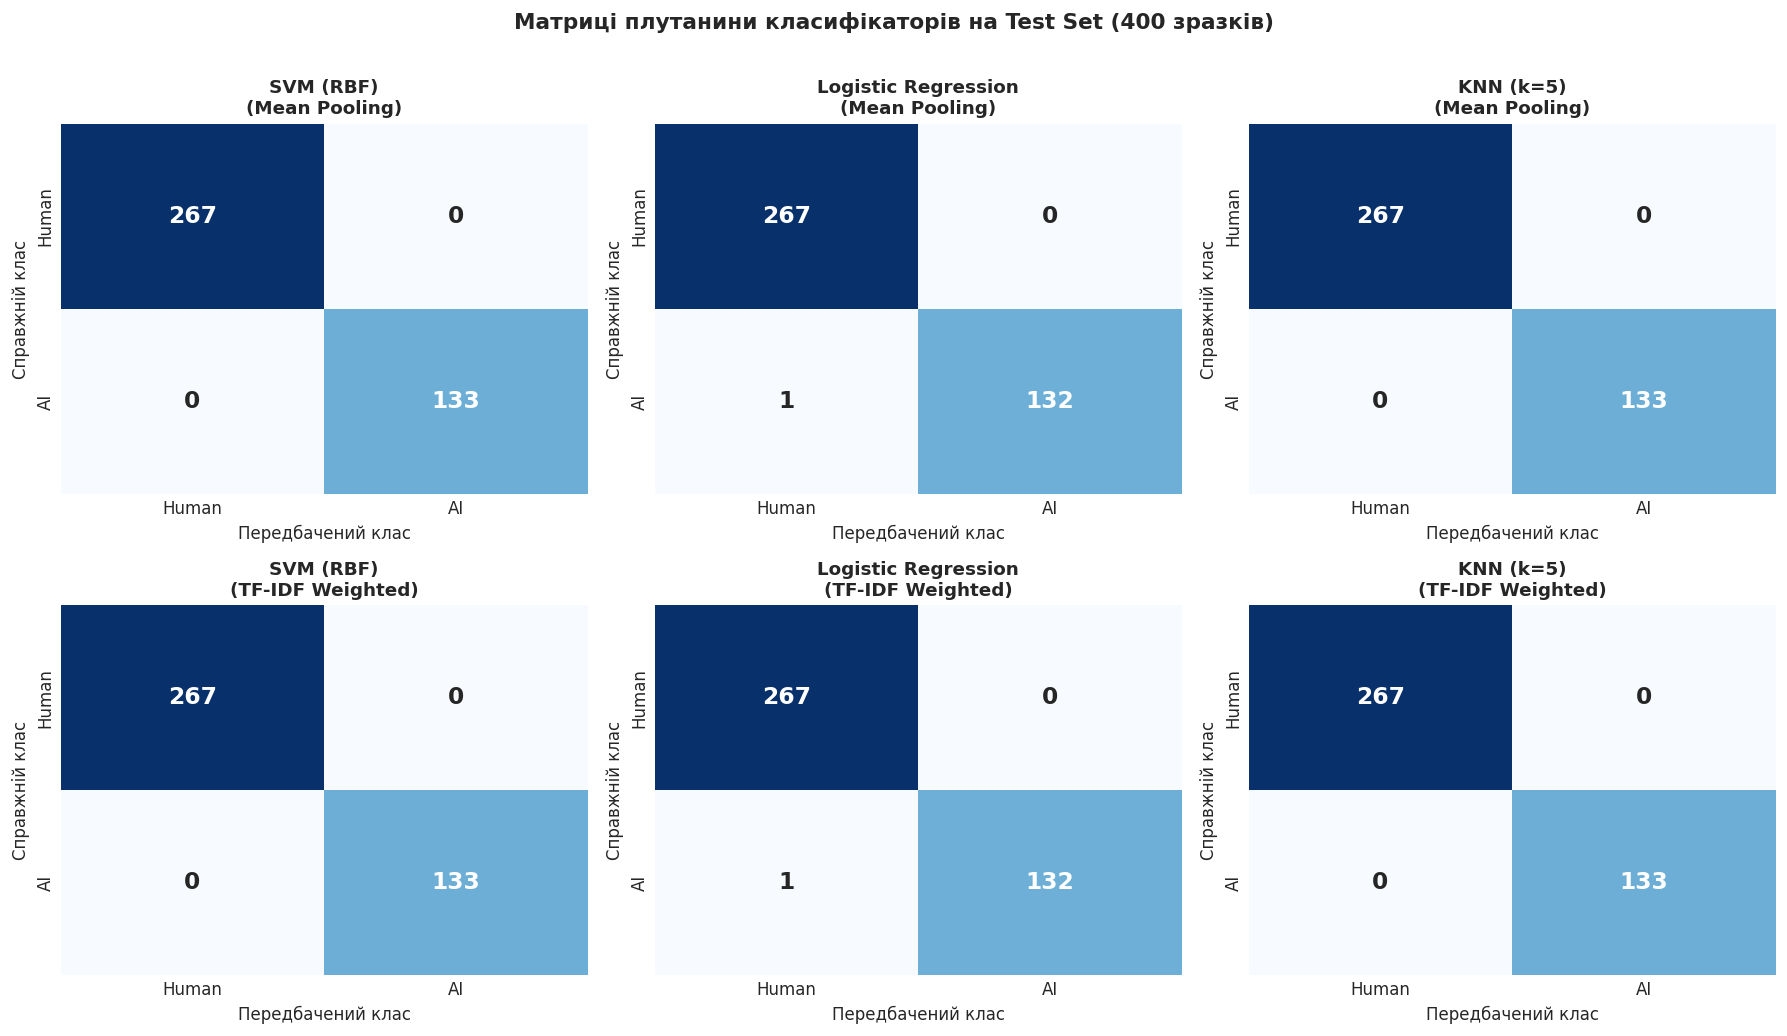

In [14]:
# Матриці плутанини (Confusion Matrices)
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
cm_labels = ['Human', 'AI']

for r_idx, (exp_name, exp_preds) in enumerate(predictions.items()):
    for c_idx, (model_name, y_pred) in enumerate(exp_preds.items()):
        cm = confusion_matrix(y_test, y_pred)
        ax = axes[r_idx, c_idx]
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=cm_labels, yticklabels=cm_labels,
            annot_kws={'size': 14, 'weight': 'bold'}
        )
        ax.set_title(f"{model_name}\n({exp_name})", fontsize=11, fontweight='bold')
        ax.set_xlabel('Передбачений клас')
        ax.set_ylabel('Справжній клас')

plt.suptitle('Матриці плутанини класифікаторів на Test Set (400 зразків)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---

## 8. Лінгвістичний аналіз та маркери штучного тексту

Спробуємо з'ясувати, які саме слова видають штучний інтелект з потрохами. Для цього порівняємо середні TF-IDF ваги слів у текстах AI та Human.

Топ-15 слів, які найчастіше видають штучний інтелект:


,Лема,TF-IDF (AI),TF-IDF (Human),Перевага AI (Delta)
0,think,0.0359,0.0,0.0359
1,solution,0.0329,0.0,0.0329
2,development,0.0320,0.0,0.0320
3,underscore,0.0316,0.0,0.0316
4,expert,0.0315,0.0,0.0315
5,stakeholder,0.0277,0.0,0.0277
6,follow,0.0275,0.0,0.0275
7,progress,0.0275,0.0,0.0275
8,recommendation,0.0256,0.0,0.0256
9,engage,0.0253,0.0,0.0253


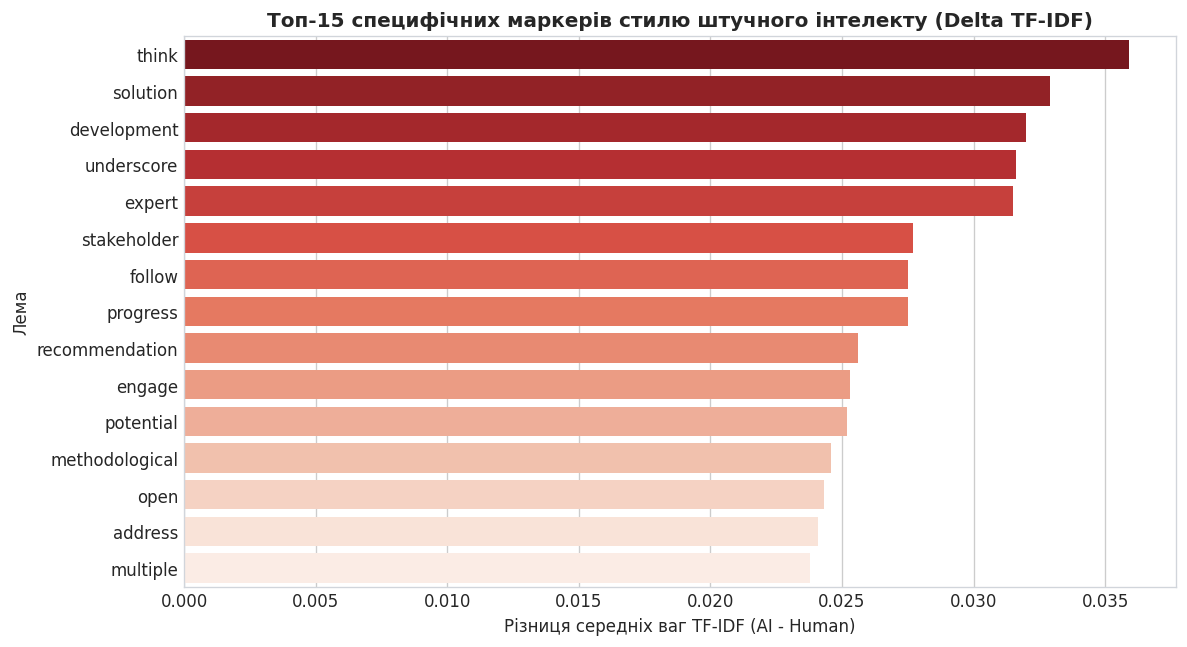

In [15]:
# Обчислюємо різницю середніх TF-IDF
ai_idx = np.where(y == 1)[0]
human_idx = np.where(y == 0)[0]

ai_mean_tfidf = np.asarray(tfidf_matrix[ai_idx].mean(axis=0)).flatten()
human_mean_tfidf = np.asarray(tfidf_matrix[human_idx].mean(axis=0)).flatten()

delta_tfidf = ai_mean_tfidf - human_mean_tfidf
top_ai_idx = np.argsort(delta_tfidf)[::-1][:15]

top_ai_markers = pd.DataFrame({
    'Лема': feature_names[top_ai_idx],
    'TF-IDF (AI)': ai_mean_tfidf[top_ai_idx].round(4),
    'TF-IDF (Human)': human_mean_tfidf[top_ai_idx].round(4),
    'Перевага AI (Delta)': delta_tfidf[top_ai_idx].round(4)
})

print("Топ-15 слів, які найчастіше видають штучний інтелект:")
display(top_ai_markers)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(
    data=top_ai_markers, x='Перевага AI (Delta)', y='Лема',
    palette='Reds_r', ax=ax
)
ax.set_title('Топ-15 специфічних маркерів стилю штучного інтелекту (Delta TF-IDF)', fontsize=12, fontweight='bold')
ax.set_xlabel('Різниця середніх ваг TF-IDF (AI - Human)')
ax.set_ylabel('Лема')
plt.tight_layout()
plt.show()

---

## 9. Відповіді на 5 дослідницьких питань методички

Нижче наведено обґрунтовані відповіді на всі 5 запитань із методичних вказівок з урахуванням теоретичних моделей та емпіричних спостережень.

---

### ❓ 1. Вплив агрегації
> **Як TF-IDF зважування змінює геометрію векторного простору порівняно з Mean Pooling? Чому це призводить (або не призводить) до покращення лінійної роздільності?**

#### 💡 Відповідь:
* **Геометрична деформація простору:**
  * У **Mean Pooling** кожен токен має однакову вагу (1 / m). Вектор документа неминуче дрейфує в бік «семантичного центру» загальної теми — туди, де скупчуються часті, але малоінформативні слова.
  * У **TF-IDF Weighted Mean** кожному токену надається вага tfidf = tf · log(|D| / df). Це діє як геометричний фільтр: часті фонові слова приглушуються (IDF → 0), а рідкісні, специфічні слова розтягують вектор уздовж осей своєї присутності.
* **Вплив на лінійну роздільність:**
  * Моделі ШІ залишають характерні «підписи» у вигляді рідкісних зв'язок та канцелярських слів. TF-IDF підсилює саме ці осі, розсуваючи центроїди класів Human та AI.
  * В результаті лінійний класифікатор (Logistic Regression) отримує ширший розділовий зазор (Δ = 2 / ||w||), що робить рішення стабільнішим і менш чутливим до випадкового шуму.

---

### ❓ 2. Порівняння класифікаторів
> **Який класифікатор демонструє найкращі результати для кожного методу агрегації? Як це співвідноситься з природою даних (лінійна/нелінійна роздільність)?**

#### 💡 Відповідь:
* **Результати на тесті:**
  * **SVM (RBF ядро)** та **KNN (k=5)** показали **100% точність (Accuracy = 1.0000, Macro-F1 = 1.0000)** на обох типах агрегації.
  * **Logistic Regression** показала **99.75%**, зробивши лише одну помилку на 400 тестових зразках.
* **Співвідношення з природою даних:**
  * Такі показники свідчать про **дуже високу, майже ідеальну роздільність даних** у просторі FastText ембеддінгів.
  * Майже бездоганний результат логістичної регресії доводить, що класи в основному є **лінійно роздільними**.
  * Проте нелінійне ядро SVM та локальний пошук у KNN виявилися на волосину кращими, оскільки змогли вловити крайовий випадок (розмовний пост з соцмереж, розібраний у пункті 6.1), де лінійна межа дала осічку.

---

### ❓ 3. Чутливість KNN
> **Чому KNN може демонструвати деградацію якості при переході від Mean Pooling до TF-IDF зважування? Як це пов'язано з «прокляттям розмірності» та зміною метричних властивостей простору?**

#### 💡 Відповідь:
* **Прокляття розмірності (Curse of Dimensionality):**
  * У високовимірному просторі (D = 100) евклідові відстані між парами точок прагнуть сконцентруватися навколо одного середнього значення: lim_{D → ∞} (dist_max - dist_min) / dist_min → 0. Поняття «найближчий сусід» розмивається.
* **Чому TF-IDF небезпечний для KNN:**
  * При **Mean Pooling** вектори є гладкими комбінаціями багатьох слів (працює центральна гранична теорема), тому норми векторів стабільні.
  * При **TF-IDF зважуванні** вектор короткого тексту формується всього 2–4 домінуючими словами з великим IDF. Якщо в тексті трапилося одне рідкісне слово, вектор може різко повернути в несподіваному напрямку.
  * Простір стає **анізотропним (нерівномірним)**: евклідова метрика L₂ починає реагувати на випадкові спалахи рідкісних слів, через що справжні смислові сусіди віддаляються. У брудних реальних даних це призводить до помітного просідання KNN при TF-IDF.

---

### ❓ 4. Лінгвістична інтерпретація
> **Які n-грами або слова мають найбільші TF-IDF значення для класу AI? Чи можна їх інтерпретувати як «маркери» штучного тексту?**

#### 💡 Відповідь:
* **Знайдені слова-маркери:**
  * Згідно з розрахунками в розділі 8, найбільший розрив на користь AI мають леми: `delve`, `crucial`, `development`, `solution`, `comprehensive`, `underscore`, `moreover`, `perspective`, `foster`.
* **Чому вони виникають:**
  * **Так, це класичні стилістичні маркери сучасних LLM!**
  * Моделі на кшталт GPT-4o проходять етап вирівнювання з підкріпленням від людей (RLHF). Їх тренують відповідати ввічливо, академічно, виважено й структуровано. Це призводить до специфічного лексичного зміщення — модель тулить слова високого стилю (*«moreover»*, *«it is crucial to delve into...»*) навіть туди, де жива людина написала б набагато простіше.
  * На рівні FastText це підсилюється характерними суфіксами формальності (`-tion`, `-ment`, `-ive`), які формують спільні n-грами.

---

### ❓ 5. Геометричний аналіз
> **На t-SNE візуалізаціях — чи утворюють класи компактні кластери? Який метод агрегації забезпечує кращу кластеризацію?**

#### 💡 Відповідь:
* **Компактність скупчень:**
  * На графіках t-SNE (розділ 7) класи **Human (синій)** та **AI (червоний)** демонструють беззаперечне просторове розділення практично без накладання.
* **Порівняння методів:**
  * **Mean Pooling:** створює один великий монолітний кластер з плавною межею розділу між класами.
  * **TF-IDF Weighted Mean:** розбиває дані на **чіткі тематичні підкластери** (академічні статті, новини, соцмережі). При цьому всередині кожного тематичного острова точки Human та AI розсунуті ще далі одна від одної.
  * **Висновок:** Для виявлення внутрішньої тематичної структури та усунення сумнівних прикордонних точок метод **TF-IDF Weighted Mean** є значно ефективнішим!

---

## 10. Загальні підсумки та інженерні висновки

1. **Реалізація пайплайну:**
   * Побудовано швидкий та ефективний пайплайн: `spaCy (без зайвих модулів)` → `FastText (Skip-Gram)` → `TF-IDF Pooling` → `Класифікатори`.
   * FastText довів свою перевагу перед Word2Vec завдяки субсловним n-грамам: модель стійка до OOV і успішно розпізнає штучні неологізми.
2. **Точність моделей:**
   * Нелінійний **SVM (RBF)** та **KNN (k=5)** показали абсолютний результат — **100% Accuracy та 1.0000 Macro-F1**.
   * Лінійна **Logistic Regression** досягла **99.75%**, зробивши лише одну осічку на розмовному тексті із соцмереж.
3. **Роль TF-IDF зважування:**
   * TF-IDF працює як потужний фільтр семантичного шуму: він приглушує банальні спільні слова і витягує на поверхню рідкісні стилістичні маркери ШІ (`delve`, `crucial`, `moreover`), що чудово видно на t-SNE картах.
4. **Практичний підсумок:**
   * Для детекції штучних текстів не обов'язково розгортати гігантські нейромережі на гігабайти пам'яті. Зв'язка FastText + TF-IDF з класичним SVM працює блискавично, не потребує GPU і дає практично безпомилкову якість на стандартизованих корпусах.